### contours inspect

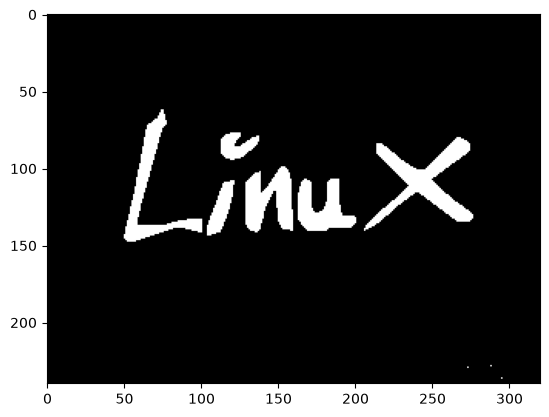

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('07_opencv\\img\\LinuxLogo.jpg', cv2.IMREAD_GRAYSCALE)
_, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)
plt.imshow(img, 'gray')

In [15]:
# find contours
cnt, hrc = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
hrc

array([[[ 1, -1, -1, -1],
        [ 2,  0, -1, -1],
        [ 3,  1, -1, -1],
        [ 4,  2, -1, -1],
        [ 5,  3, -1, -1],
        [ 6,  4, -1, -1],
        [ 7,  5, -1, -1],
        [ 8,  6, -1, -1],
        [-1,  7, -1, -1]]], dtype=int32)

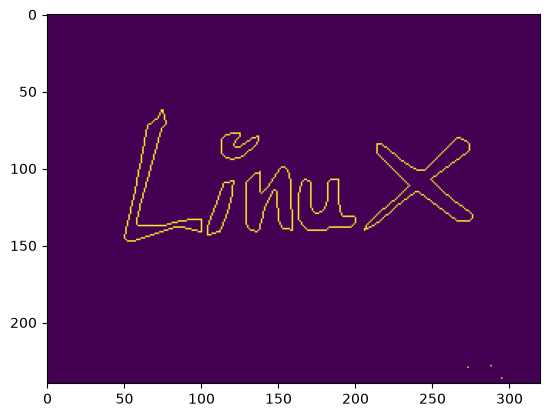

In [13]:
# draw contours
n_img = np.zeros_like(img)

cv2.drawContours(n_img, cnt, -1, (255,0,0), 1)
plt.imshow(n_img)

In [30]:
# contours area 
for c in cnt:
    area = cv2.contourArea(c)
    print(len(c), area, c.shape)

# filter
vld_cnt = [c for c in cnt if cv2.contourArea(c) > 100]
type(vld_cnt)

1 0.0 (1, 1, 2)
1 0.0 (1, 1, 2)
1 0.0 (1, 1, 2)
49 283.5 (49, 1, 2)
41 667.5 (41, 1, 2)
62 770.5 (62, 1, 2)
89 1184.0 (89, 1, 2)
34 238.5 (34, 1, 2)
118 819.0 (118, 1, 2)


list

In [28]:
# arc length
for v in vld_cnt:
    print(cv2.arcLength(v, True))


90.5269113779068
165.8406195640564
196.46803617477417
319.73000955581665
85.84061932563782
285.6812391281128


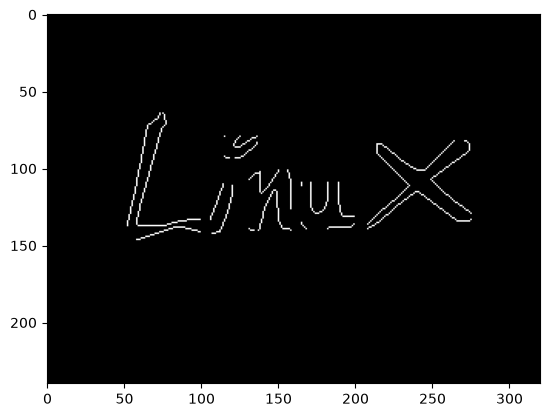

In [32]:
# 计算轮廓边界矩形


for c in cnt:
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(n_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(n_img, 'gray')

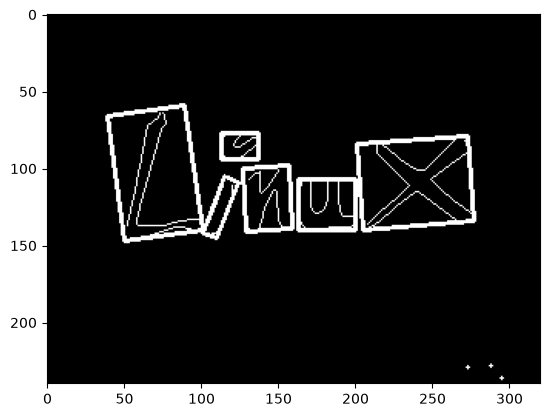

In [44]:
# min area rectangle
for c in cnt:
    rct = cv2.minAreaRect(c)
    # print(rct)
    bx = cv2.boxPoints(rct)
    # print(bx)
    bx = bx.astype(np.int32)
    cv2.drawContours(n_img, [bx], 0, (255,0,0), 2)

plt.imshow(n_img, 'gray')


295.0 236.0
273.0 229.0
288.0 228.0
112.5 125.5
182.0891876220703 122.55300903320312
145.5 120.84146118164062
240.0 112.0
125.0 84.5
71.3272476196289 106.61795806884766


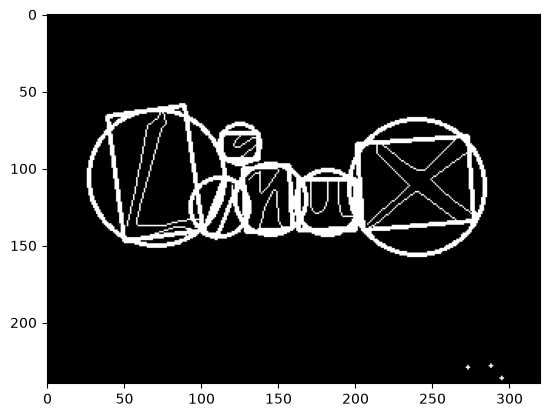

In [50]:
# min area circle
for c in cnt:
    (x,y), rad = cv2.minEnclosingCircle(c)
    print(x,y)
    ctr = (int(x), int(y))
    rad = int(rad)
    cv2.circle(n_img, ctr, rad, (255,0,0), 2)
plt.imshow(n_img, 'gray')